In [1]:
import matplotlib
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import yfinance
import certifi

## Read dataset and check overview

In [2]:
df=pd.read_csv('/Users/vithaovu/Documents/hocthem2/netflix-content-analysis/data/Netflix.csv')

In [3]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


- Chú thích:
    + show_id: Mã định danh duy nhất của từng nội dung
    + type: Loại nội dung – thường là Movie (phim lẻ) hoặc TV Show (phim/series).
    + director: Đạo diễn. Có thể NaN nếu không ghi nhận (đặc biệt nhiều TV Show).
    + cast: Danh sách diễn viên, dạng chuỗi ngăn cách bằng dấu phẩy. Có thể NaN.
    + country: Quốc gia sản xuất/phát hành. Có thể nhiều quốc gia, ngăn cách bằng dấu phẩy; cũng có thể NaN.
    + date_added: Ngày Netflix thêm nội dung lên nền tảng (chuỗi kiểu dd-MMM-yy, ví dụ 25-Sep-21). Dùng để phân tích theo thời gian “lên sóng” trên Netflix, khác với năm sản xuất.
    + release_year: Năm phát hành/sản xuất của nội dung (số nguyên, ví dụ 2021).
    + rating: Phân loại độ tuổi (ví dụ PG-13, TV-MA, R…). Có thể thiếu.
    + duration:
        + Với Movie: thời lượng tính bằng phút (ví dụ 90 min).
        + Với TV Show: số Seasons (ví dụ 2 Seasons, 1 Season).
    + listed_in: Thể loại/nhóm nội dung (genres) – chuỗi có thể chứa nhiều nhãn, ngăn cách bằng dấu phẩy (ví dụ: International TV Shows, TV Dramas, TV Mysteries).
    + description: Mô tả ngắn nội dung

In [4]:
df.tail(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,1-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2-Mar-19,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df.duplicated().any()

False

## Tiền xử lý

In [9]:
#date_added -> datetime + tách year/month/quarter
df["date_added_dt"] = pd.to_datetime(df["date_added"], errors="coerce", dayfirst=True)
df["added_year"]   = df["date_added_dt"].dt.year
df["added_month"]  = df["date_added_dt"].dt.month
df["added_quarter"]= df["date_added_dt"].dt.quarter

In [10]:
for c in ["added_year", "added_month", "added_quarter"]:
    df[c] = df[c].astype("Int64")   # không cần round vì các giá trị vốn là số nguyên

In [11]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_dt,added_year,added_month,added_quarter
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,2021,9,3
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021,9,3
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,2021,9,3
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021-09-24,2021,9,3
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021-09-24,2021,9,3


In [12]:
#duration -> duration_min (Movie), seasons (TV Show)
#Lấy số trong chuỗi duration
num_in_duration = df["duration"].astype(str).str.extract(r"(\d+)")[0].astype("float")

df["duration_min"] = np.where(df["type"].str.lower().eq("movie"), num_in_duration, np.nan)
df["seasons"]      = np.where(df["type"].str.lower().eq("tv show"), num_in_duration, np.nan)

In [13]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_added_dt,added_year,added_month,added_quarter,duration_min,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,2021,9,3,90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021,9,3,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021-09-24,2021,9,3,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021-09-24,2021,9,3,NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021-09-24,2021,9,3,NaN,2.0


In [14]:
#listed_in -> one-hot (multi-label)
# Chuẩn hóa khoảng trắng sau dấu phẩy để tránh tạo cột trùng do khoảng trắng
listed_norm = df['listed_in'].fillna('').str.replace(r',\s*', ',', regex=True)  
genres_dummies = listed_norm.str.get_dummies(sep=',')
if '' in genres_dummies.columns:
    genres_dummies = genres_dummies.drop(columns=[''])
df = pd.concat([df, genres_dummies.add_prefix('genre_')], axis=1)

In [15]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Mysteries,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_TV Thrillers,genre_Teen TV Shows,genre_Thrillers
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,...,0,0,0,0,0,0,0,0,0,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,...,0,0,1,0,1,0,0,0,0,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,...,1,0,0,0,0,0,0,0,0,0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,...,0,0,0,0,0,0,0,0,0,0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,...,0,1,0,0,0,0,0,0,0,0


### Xử lý NaN 

In [16]:
print("Giá trị null của rating trước:", df['rating'].isna().sum())
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
print("Giá trị null của rating sau:", df['rating'].isna().sum())

Giá trị null của rating trước: 4
Giá trị null của rating sau: 0


In [17]:
# Movie: điền duration_min theo median từng năm phát hành phù hợp 
mask_movie = df["type"].str.lower().eq("movie")
df.loc[mask_movie, "duration_min"] = (
    df.loc[mask_movie].groupby("release_year")["duration_min"]
      .transform(lambda s: s.fillna(s.median()))
)

In [18]:
mask_movie = df["type"].str.lower().eq("movie")
print("Tổng Movie:", mask_movie.sum(),
      "| duration_min còn thiếu (trong Movie):", df.loc[mask_movie, "duration_min"].isna().sum())

Tổng Movie: 6131 | duration_min còn thiếu (trong Movie): 0


In [19]:
# TV Show: điền seasons còn thiếu = 1 (giả định tối thiểu) hoặc theo median từng năm
mask_tv = df["type"].str.lower().eq("tv show")
df.loc[mask_tv, "seasons"] = (
    df.loc[mask_tv, "seasons"].fillna(
        df.loc[mask_tv].groupby("release_year")["seasons"]
          .transform(lambda s: s.median())
    )
)

In [20]:
df['duration_min'] = df['duration_min'].round().astype('Int64')
df['seasons']      = df['seasons'].round().astype('Int64')

In [21]:
mask_tv    = df["type"].str.lower().eq("tv show")
print("Tổng TV Show:", mask_tv.sum(),
      "| seasons còn thiếu (trong TV):", df.loc[mask_tv, "seasons"].isna().sum())

Tổng TV Show: 2676 | seasons còn thiếu (trong TV): 0


In [22]:
# Country thiếu → Unknown (nếu cần nhóm chung để đếm)
df["country_final"] = df["country"].fillna("Unknown")

In [23]:
print("Giá trị null của date_added trước:", df['date_added'].isna().sum())
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
print("Giá trị null của date_added sau:", df['date_added'].isna().sum())

Giá trị null của date_added trước: 10
Giá trị null của date_added sau: 0


## Phân tích

### Thống kê số liệu title theo thời gian

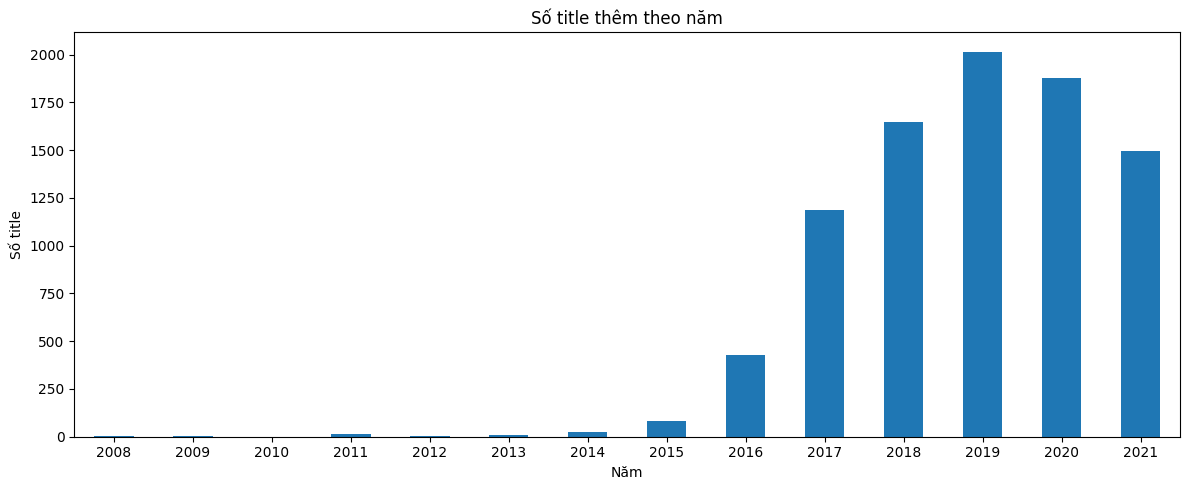

In [24]:
#Tổng title(tên phim) theo năm
df_time = df.dropna(subset=["date_added_dt"]).copy()
cnt_year = df_time.groupby("added_year")["show_id"].count()

fig = plt.figure(figsize=(12,5))
ax = cnt_year.plot(kind="bar")
ax.set_title("Số title thêm theo năm")
ax.set_xlabel("Năm")
ax.set_ylabel("Số title")

for label in ax.get_xticklabels():
    label.set_rotation(0)      # 0 độ = nằm ngang
    label.set_ha("center")     # canh giữa
plt.tight_layout()

plt.savefig(
    "../images/titles_added_by_year.png",
    bbox_inches='tight'
)

plt.show()

Tốc độ tăng trưởng của title theo từng năm:
- Tăng tốc mạnh từ 2016: số nội dung thêm mới tăng lên rõ rệt sau 2016 → giai đoạn phát triển mạng mẽ.
- Đạt đỉnh 2019–2020: 2019 cao nhất, 2020 vẫn rất cao → Netflix duy trì nhịp tăng trưởng nội dung lớn (dù năm 2020 có COVID).
- Giảm ở 2021: thấp hơn 2019–2020.
- Giai đoạn trước 2015: gần như không đáng kể → thị trường/chiến lược khi đó còn nhỏ.

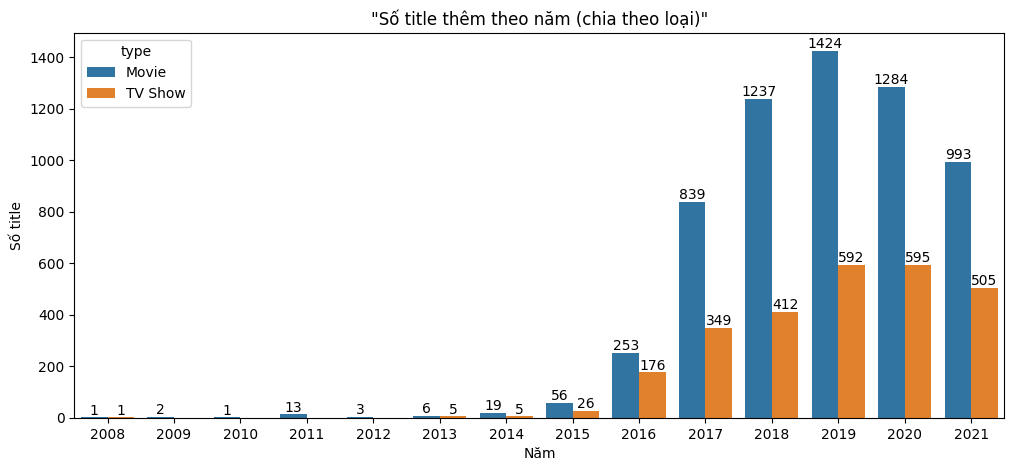

In [25]:
#Tổng title(tên phim) theo năm và type
plt.figure(figsize=(12,5))
ax= sns.countplot(data=df,x='added_year',hue ='type')
ax.bar_label(ax.containers[0],fontsize=10,fmt = '{:.0f}')
ax.bar_label(ax.containers[1],fontsize=10,fmt = '{:.0f}')
plt.title('"Số title thêm theo năm (chia theo loại)"')
plt.ylabel("Số title")
plt.xlabel("Năm")

plt.savefig(
    "../images/movie_tv_by_year.png",
    bbox_inches='tight'
)
plt.show()

- Nhìn chung Movie luôn chiếm tỷ trọng lớn hơn TV Show qua các năm.
- Để hiểu rõ hơn chúng ta cần vẽ biểu đồ tỉ lệ để hiểu rõ hơn

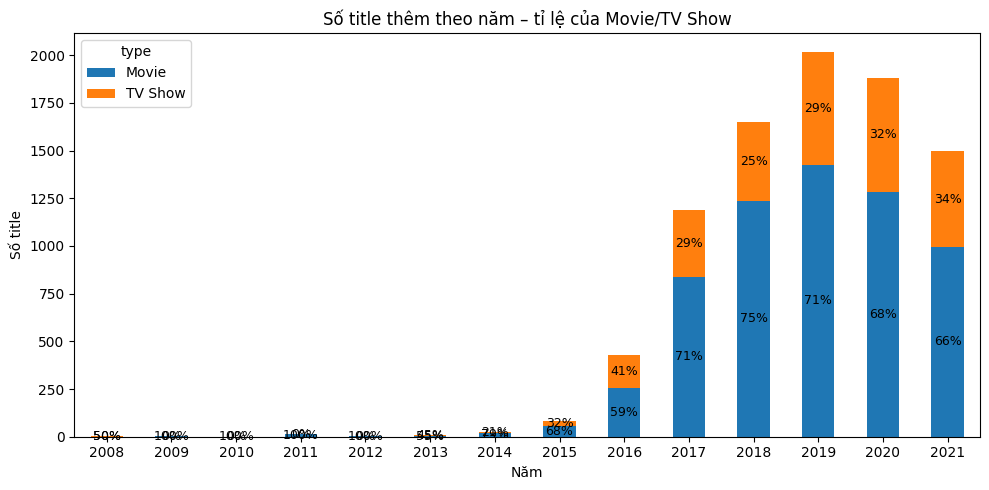

In [26]:
#tỉ lệ title(tên phim) theo năm và type
df_time = df.dropna(subset=["date_added_dt"]).copy()
tbl = (df_time.groupby(["added_year","type"])["show_id"]
       .count().unstack(fill_value=0).sort_index())
ax = tbl.plot(kind="bar", stacked=True, figsize=(10,5))
ax.set_title("Số title thêm theo năm – tỉ lệ của Movie/TV Show")
ax.set_xlabel("Năm"); ax.set_ylabel("Số title")
for lbl in ax.get_xticklabels(): lbl.set_rotation(0)
tot = tbl.sum(axis=1)
for i, year in enumerate(tbl.index):
    cum = 0
    for col in tbl.columns:
        val = tbl.loc[year, col]; cum += val
        pct = 0 if tot.loc[year]==0 else val/tot.loc[year]*100
        ax.text(i, cum - val/2, f"{pct:.0f}%", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

=> Kết luận: 
- Movie luôn chiếm đa số: khoảng 59–75% mỗi năm.
- TV Show có nhiều biến động:
    + 2016: ~41% (giai đoạn push TV)
    + 2017–2018: giảm còn 29% → 25% (Movie áp đảo)
    + 2019–2021: tăng lại lên 29% → 32% → 34%
- Nghĩa là sau khi Movie chiếm ưu thế giai đoạn bùng nổ, tỷ trọng TV Show đã quay lại đà tăng trưởng từ 2019.

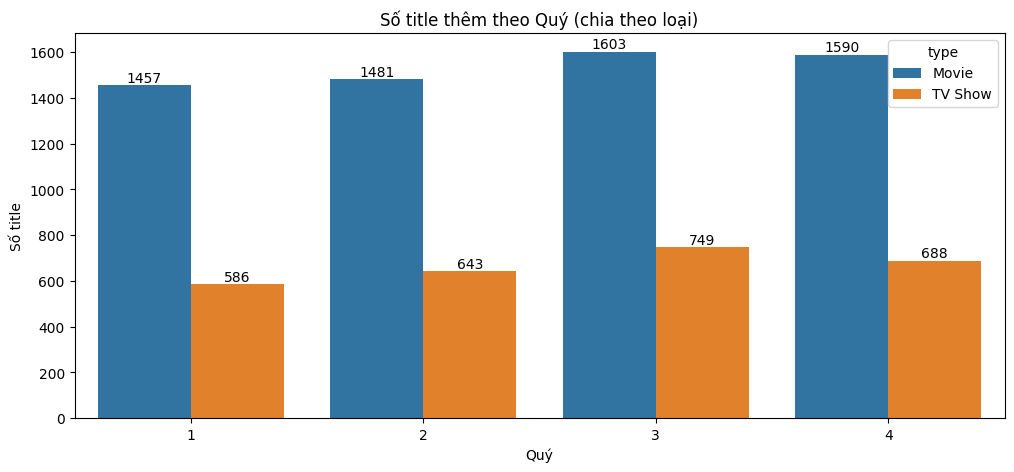

In [27]:
# Thống kê số lượng Movie và TV Show theo quý
plt.figure(figsize=(12,5))
ax = sns.countplot(data=df, x="added_quarter", hue="type", order=[1,2,3,4])
ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=10)
ax.bar_label(ax.containers[1], fmt="%.0f", fontsize=10)
plt.title("Số title thêm theo Quý (chia theo loại)")
plt.xlabel("Quý")
plt.ylabel("Số title")
plt.show()

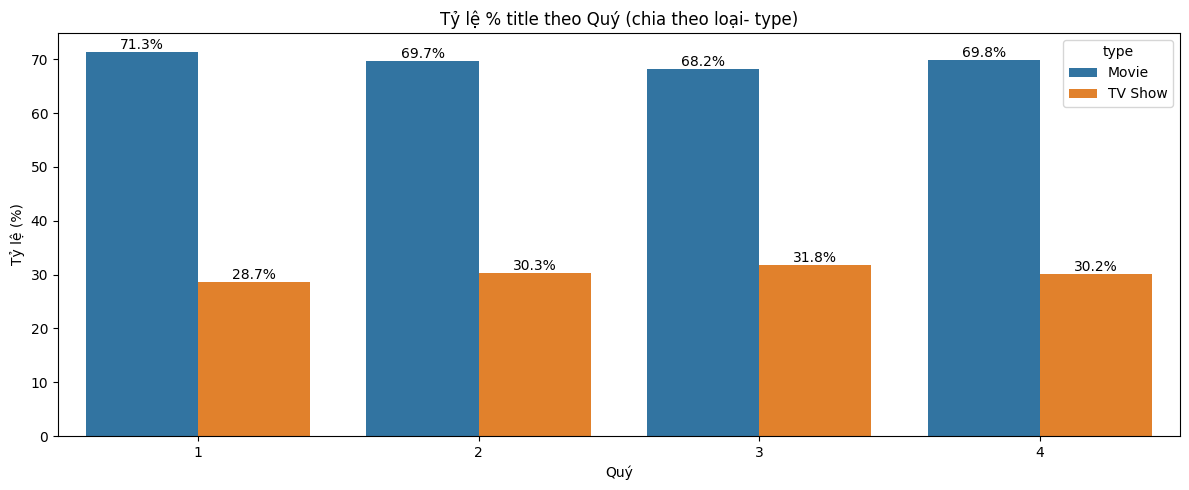

In [28]:
# Tỉ lệ Movie và TV Show theo quý
plt.figure(figsize=(12,5))
count_df = df.groupby(['added_quarter','type'])['title'].size().reset_index(name='count')
count_df['added_quarter'] = count_df['added_quarter'].astype(int)
total_per_type = count_df.groupby('added_quarter')['count'].transform('sum')
count_df['Percentage']= count_df['count']/total_per_type*100
ax= sns.barplot(data = count_df,x = 'added_quarter',y='Percentage',hue ='type' ,order=[1,2,3,4])
for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',fontsize=10)
plt.title('Tỷ lệ % title theo Quý (chia theo loại- type)')
plt.ylabel('Tỷ lệ (%)')
plt.xlabel('Quý')
plt.tight_layout()
plt.show()

- Tổng kết:
    + Q1: Movie 1457, TV 586 → tổng 2043, Movie chiếm 71,3% và TV Show chiếm 28.7%.
    + Q2: Movie 1481, TV 643 → tổng 2124, Movie chiếm 69,7% và TV Show chiếm 30,3%.
    + Q3 (đỉnh): Movie 1,603, TV 749 → tổng 2352, Movie chiếm 68,2% và TV Show chiếm ≈31,8%.
    + Q4: Movie 1590, TV 688 → tổng 2278, Movie chiếm 69,8% và TV Show chiếm 30,2%.
- Xu hướng phát triển:
    + Cao điểm vào Q3, sau đó nhẹ lại ở Q4 cho cả hai loại.
    + Tỷ trọng TV tăng dần từ Q1 → Q3 (28.7% → 31.8%), rồi giảm nhẹ ở Q4 (~30.2%).
    + Movie luôn áp đảo về số lượng (gấp ~2.3 lần TV), nhưng TV có tốc độ tăng quý/quý cao hơn trong nửa đầu năm:
    + TV: Q1→Q2 +9.7%, Q2→Q3 +16.5%, Q3→Q4 −8.1%.
    + Movie: Q1→Q2 +1.6%, Q2→Q3 +8.2%, Q3→Q4 −0.8%.
- Kết luận: Tỉ lệ của TV Show và Movie không có biến động quá nhiều qua các quý. Số lượng Movie tăng cao hơn ở quý 3 và 4 vì đây là thời gian nghỉ hè và mùa cuối năm, lễ hội mọi người có xu hướng xem Movie và TV Show nhiều hơn so với 2 quý đầu năm nên thời gian này các nhà sản xuất có xu hướng phát hàng phim nhiều hơn.

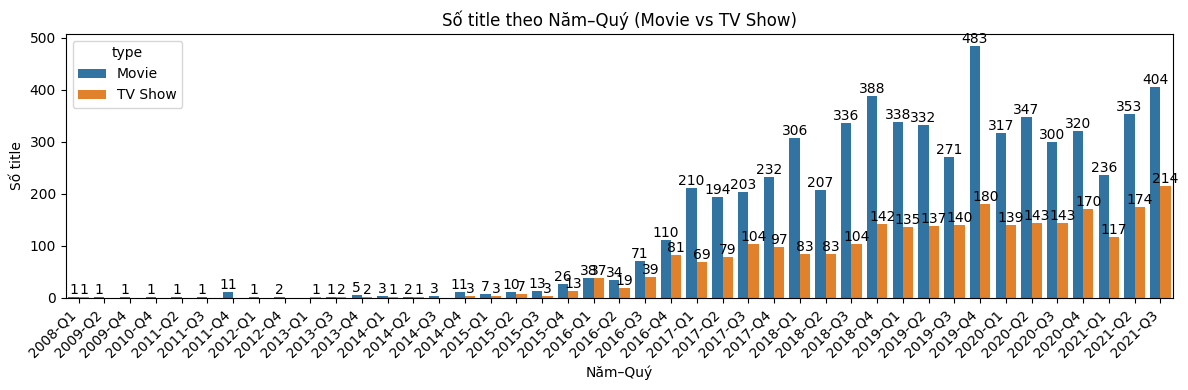

In [29]:
df_q = df.dropna(subset=["date_added_dt"]).copy()
df_q["yq"] = df_q["added_year"].astype(int).astype(str) + "-Q" + df_q["added_quarter"].astype(int).astype(str)
plt.figure(figsize=(12,4))
order = sorted(df_q["yq"].unique())  # giúp đảm bảo đúng thứ tự thời gian
ax = sns.countplot(data=df_q, x="yq", hue="type", order=order)
ax.bar_label(ax.containers[0], fmt="%.0f"); ax.bar_label(ax.containers[1], fmt="%.0f")
plt.xticks(rotation=45, ha="right")
ax.set_title("Số title theo Năm–Quý (Movie vs TV Show)")
ax.set_xlabel("Năm–Quý")
ax.set_ylabel("Số title")
plt.tight_layout()
plt.show()

- Nhận xét:
    + Bùng nổ từ 2016: trước 2015 hầu như rất ít nội dung; từ 2016 Q2–Q4 số title tăng mạnh và giữ nhịp cao tới 2019.
    + Đỉnh tuyệt đối Q3-2019  (cột cao nhất ~483 title). 2019 nhìn chung là năm cao điểm cho cả Movie lẫn TV.
    + Giảm rõ rệt trong 2020: hầu hết quý 2020 thấp hơn 2019 (phù hợp bối cảnh gián đoạn sản xuất/phát hành do dịch COVID).
    + Phục hồi trong 2021: các quý 2021 tăng trở lại so với 2020, nhưng chưa về mức đỉnh 2019.
- Kết luận: Movie vẫn áp đảo ở mọi quý nhưng: Tỷ trọng TV Show tăng dần từ sau 2018–2019 đặc biệt ở Q3- 2021 phần TV tăng mạnh

### Thống kê số lượng các thể loại phim và show

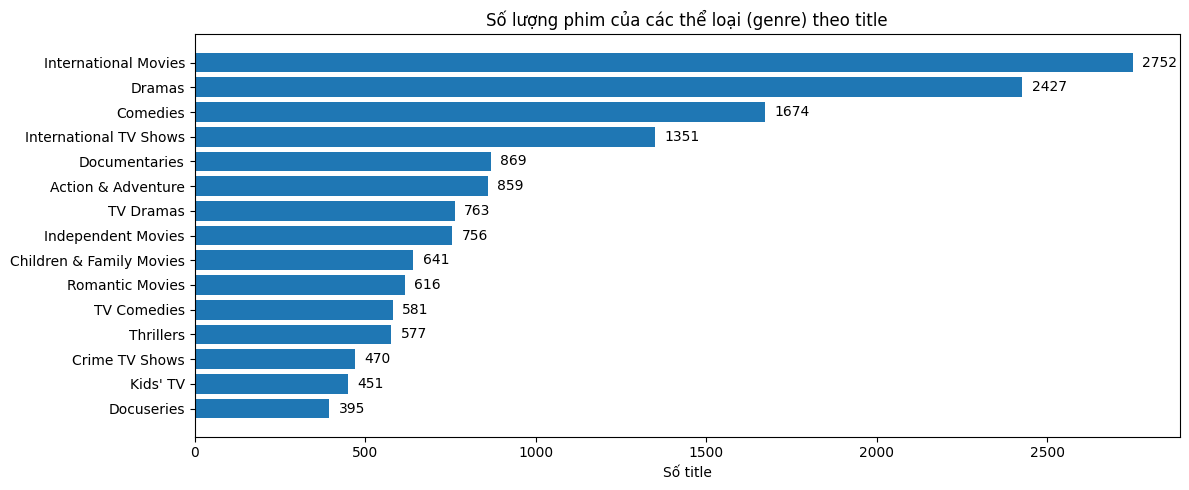

In [30]:
# Thống kê số lượng các thể loại của phim và show
genre_cols   = [c for c in df.columns if c.startswith("genre_")]
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(15)
# Làm đẹp nhãn (bỏ prefix 'genre_')
labels = [c.replace("genre_","") for c in genre_counts.index]
# Vẽ barh
plt.figure(figsize=(12,5))
bars = plt.barh(range(len(genre_counts)), genre_counts.values)
plt.yticks(range(len(genre_counts)), labels)
plt.title("Số lượng phim của các thể loại (genre) theo title")
plt.xlabel("Số title")
plt.gca().invert_yaxis()  # top nằm trên
# Ghi con số ở cuối thanh
for i, v in enumerate(genre_counts.values):
    plt.text(v + max(genre_counts)*0.01, i, str(int(v)), va="center")
plt.tight_layout()
plt.savefig(
    "../images/top_genres.png",
    bbox_inches='tight'
)
plt.show()

- Nhận xét:
    + International Movies (2,752) là lớn nhất và như tìm hiểu đây là 1 nhãn ô-dù (umbrella) cho mọi phim quốc tế xuất xứ ngoài Mỹ.
    + International TV Shows (1,351) đứng thứ 4 → danh mục với nội dung toàn cầu chiếm số lượng rất cao trong top thể loại, đây là 1 nhãn ô-dù (umbrella) cho mọi phim quốc tế xuất xứ ngoài Mỹ.
    + Movie chiếm ưu thế trong top: Với nhiều hạng mục thuộc phim vượt trội so với TV tương ứng (Dramas 2,427; Comedies 1,674; Action & Adventure 859; Independent 756; Romantic 616…).
    + Các TV Show xuất hiện nhưng ít hơn Movie như (TV Dramas 763; TV Comedies 581; Crime TV 470; Kids’ TV 451).
    + Documentaries (869) và Docuseries (395) cộng lại khá lớn → nhu cầu nội dung tài liệu đáng kể.
    + Chương trình dành cho gia đình & trẻ em chiếm số lượng ít: Children & Family Movies (641) và Kids’ TV (451) → mảng an toàn cho tăng trưởng đều.

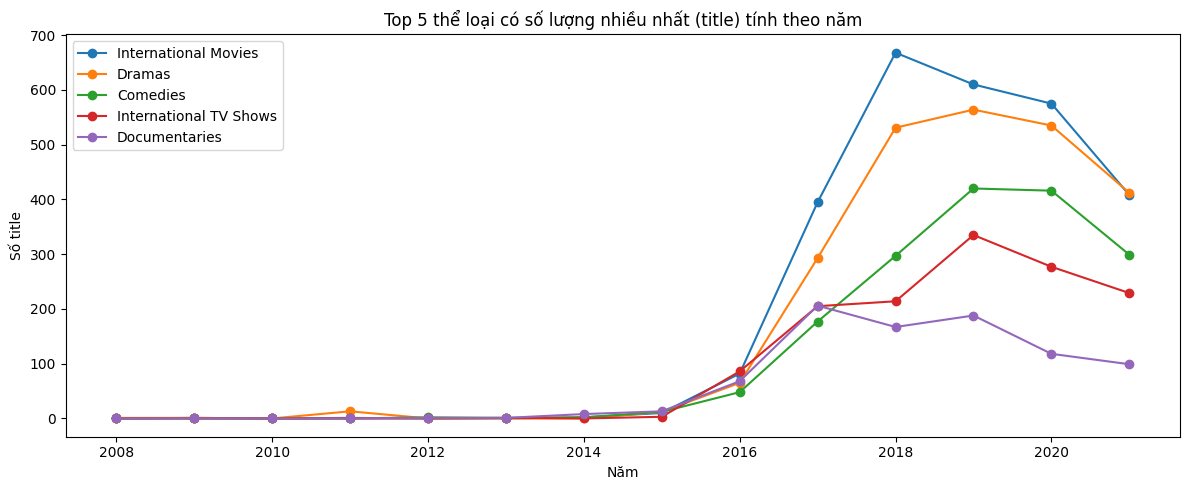

In [31]:
# Thống kê 5 thể loại phim nhiều nhất và quá trình tăng trưởng của nó
df_time = df.dropna(subset=["date_added_dt"]).copy()
genre_cols = [c for c in df.columns if c.startswith("genre_")]
YG = df_time.groupby("added_year")[genre_cols].sum().sort_index()
topN = 5
top_genres = YG.sum().sort_values(ascending=False).head(topN).index
YG_top = YG[top_genres]
plt.figure(figsize=(12,5))
for c in YG_top.columns:
    plt.plot(YG_top.index, YG_top[c], marker="o", label=c.replace("genre_",""))
plt.title("Top 5 thể loại có số lượng nhiều nhất (title) tính theo năm")
plt.xlabel("Năm")
plt.ylabel("Số title")
plt.legend()
plt.tight_layout()
plt.show()

- Nhận xét:
    + Từ 2008-2015: gần như phẳng và chưa có sự phát triển hay khác biệt giữa các thể loại
    + Bùng nổ 2016 → 2019 ở tất cả các thể loại (genre) đều có sự tăng trưởng mạnh mẽ
    + International Movies dẫn đầu toàn giai đoạn, đỉnh ~2018, sau đó giảm dần 2019–2021 nhưng vẫn cao hơn các genre khác.
    + Dramas và Comedies bứt phá mạnh sau 2016, đạt đỉnh ~2019/2020, rồi hạ nhiệt 2021.
    + International TV Shows tăng mạnh từ 2015-2017 sau đó chững lại 1 năm rồi phát triển nhưng lại tiếp tục nhưng giảm khá rõ 2020–2021.
    + Documentaries cũng tăng tốt đến 2019, rồi đi xuống 2020–2021.

In [32]:
# Cặp thể loại đồng xuất hiện nhiều (co-occurrence)
import itertools, collections
pairs = collections.Counter()
for _, row in df[genre_cols].iterrows():
    gs = [c[6:] for c in genre_cols if row[c]==1]  
    for a,b in itertools.combinations(sorted(gs), 2):
        pairs[(a,b)] += 1
sorted(pairs.items(), key=lambda x: x[1], reverse=True)[:15]

[(('Dramas', 'International Movies'), 1483),
 (('Comedies', 'International Movies'), 804),
 (('Dramas', 'Independent Movies'), 588),
 (('International TV Shows', 'TV Dramas'), 514),
 (('Comedies', 'Dramas'), 502),
 (('Action & Adventure', 'International Movies'), 398),
 (('International Movies', 'Romantic Movies'), 372),
 (('International TV Shows', 'Romantic TV Shows'), 315),
 (('Dramas', 'Romantic Movies'), 308),
 (('Crime TV Shows', 'International TV Shows'), 299),
 (('Documentaries', 'International Movies'), 296),
 (('Independent Movies', 'International Movies'), 292),
 (('Comedies', 'Romantic Movies'), 277),
 (('International Movies', 'Thrillers'), 272),
 (('Children & Family Movies', 'Comedies'), 270)]

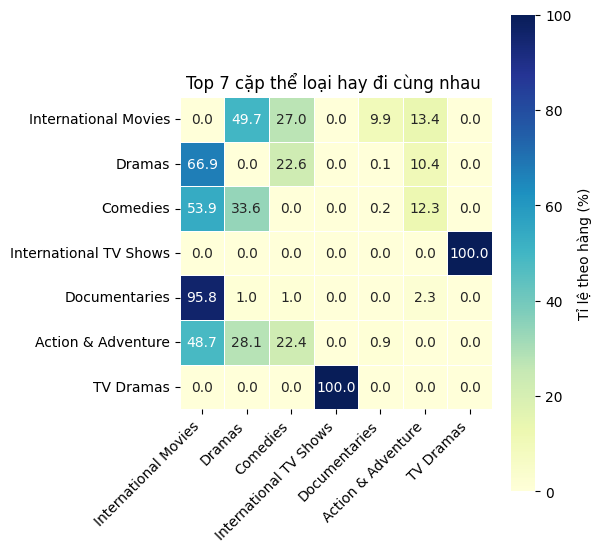

In [33]:
# 1) Top 7 genres
genre_cols = [c for c in df.columns if c.startswith("genre_")]
G = df[genre_cols].astype(int)
top7 = G.sum().sort_values(ascending=False).head(7).index
# 2) Ma trận đồng xuất hiện
M = (G[top7].T @ G[top7]).astype(int)
np.fill_diagonal(M.values, 0)
# M: ma trận đếm co-occurrence (đang dùng để vẽ), kiểu DataFrame
M_pct_row = M.div(M.sum(axis=1), axis=0) * 100   # normalize theo HÀNG
# 3) Vẽ heatmap
plt.figure(figsize=(6,6))
ax = sns.heatmap(M_pct_row, cmap="YlGnBu",annot=True,fmt=".1f",linewidths=0.5, square=True, cbar_kws={"label": "Tỉ lệ theo hàng (%)"})
# Làm đẹp nhãn
ax.set_xticklabels([c.replace("genre_","") for c in M.columns], rotation=45, ha="right")
ax.set_yticklabels([c.replace("genre_","") for c in M.index], rotation=0)
ax.set_title("Top 7 cặp thể loại hay đi cùng nhau ")
plt.tight_layout()
plt.savefig(
    "../images/genre_heatmap.png",
    bbox_inches='tight'
)
plt.show()

- Nhận xét:
    + International Movies + Dramas (≈49.7%) và + Comedies (≈27%) chiếm phần trăm khá cao và có số lượng nhiều nhất trong phim. Và ngược lại
    + TV Dramas + International TV Shows: 100%. Gần như mọi TV Show thuộc thể loại TV Dramas thì cũng sẽ đi cùng thể loại International TV Shows. Đây là cặp “đồng xuất hiện” mạnh nhất ở mảng TV Show.
    + Documentaries + International Movies (≈95.8%) cũng chiếm tỷ lệ khá cao gần 100%.
    + Action & Adventure + International Movies (≈48.7%), + Dramas (≈28.1%), + International TV Shows (≈22.4%). Thể loại hành động–phiêu lưu thường đi cùng “International”.

### Thống kê số lượng rating theo năm

In [34]:
counts = df["rating"].value_counts()
counts

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [35]:
# xoá các giá trị sai
# 1) Tạo mask bắt các giá trị kiểu thời lượng
rat = df['rating'].astype(str).str.strip()
mask_min = rat.str.contains(r'^\d+\s*min(s|ute|utes)?$', case=False, na=False)
# (tuỳ chọn) xem trước sẽ xoá bao nhiêu dòng và là những gì
print(df.loc[mask_min, 'rating'].value_counts())
# 2) Xoá những dòng này
df = df.loc[~mask_min].copy()
# 3) Kiểm tra lại
assert not df['rating'].astype(str).str.contains('min', case=False, na=False).any()

rating
74 min    1
84 min    1
66 min    1
Name: count, dtype: int64


In [36]:
counts = df["rating"].value_counts()
counts

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

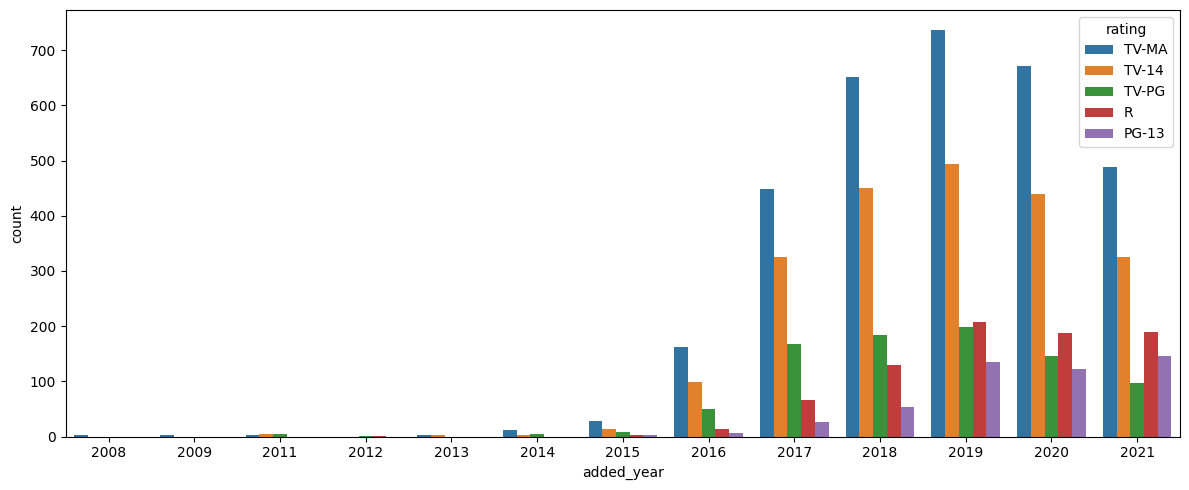

In [37]:
# Top 5 rating theo năm
plt.figure(figsize=(12,5))
top_r = df["rating"].value_counts().head(5).index
df_plot = (
    df_time[df_time["rating"].isin(top_r)]
    .groupby(["added_year","rating"], as_index=False)["show_id"].count()
    .rename(columns={"show_id": "count"})
    .sort_values("added_year")
)
ax = sns.barplot(data=df_plot, x="added_year", y="count", hue="rating")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

### Thống kê và phân tích country

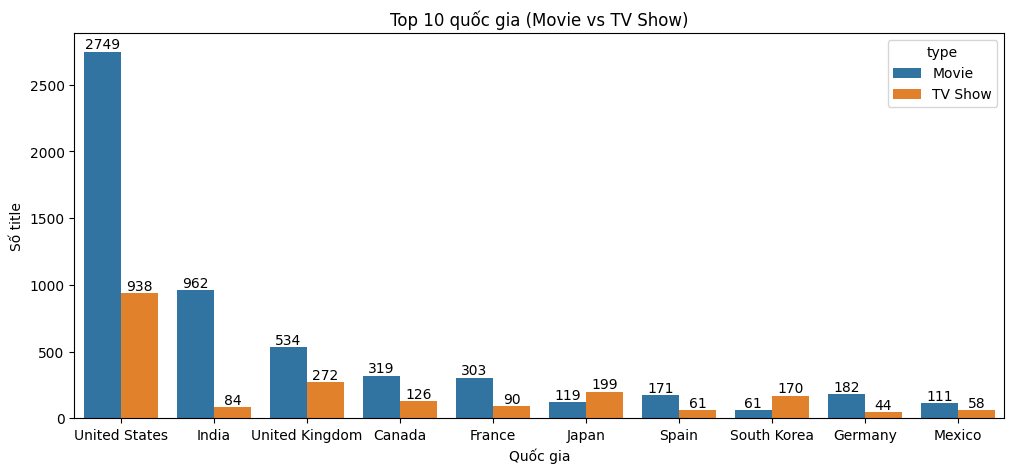

In [38]:
# Tách country 
tmp = df.assign(country=df["country"].str.split(",")).explode("country")
tmp["country"] = tmp["country"].str.strip()
# Top 10 quốc gia theo tổng số title
top10  = tmp["country"].value_counts().head(10).index
cty    = (tmp[tmp["country"].isin(top10)]
          .groupby(["country","type"]).size().reset_index(name="count"))
order  = cty.groupby("country")["count"].sum().sort_values(ascending=False).index
# Cột nhóm (Movie vs TV Show)
plt.figure(figsize=(12,5))
ax = sns.barplot(data=cty, x="country", y="count", hue="type", order=order)
ax.bar_label(ax.containers[0],fmt='{:.0f}',fontsize=10)
ax.bar_label(ax.containers[1],fmt='{:.0f}',fontsize=10)
plt.title('Top 10 quốc gia (Movie vs TV Show)')
plt.ylabel('Số title')
plt.xlabel('Quốc gia')
plt.savefig(
    "../images/top_countries.png",
    bbox_inches='tight'
)
plt.show()

- United States áp đảo: tổng title vượt trội và độ chênh Movie >> TV Show. Mỹ là nguồn nội dung chủ lực.
- India đứng thứ 2: chủ yếu là Movie, TV Show còn ít hơn đáng kể → thị trường điện ảnh Ấn phát triển mạnh.
- United Kingdom & Canada: quy mô trung bình; Movie vẫn nhỉnh hơn TV, nhưng khoảng cách hẹp hơn Ấn/Mỹ.
- France, Spain, Germany, Japan, Mexico: nhóm đuôi Top 10; cơ cấu nghiêng Movie nhiều hơn TV.
- South Korea: tổng không lớn như US/India nhưng tỷ trọng TV Show cao hơn tương đối (phù hợp xu hướng K-drama/series).
- Nhìn chung, Movie chiếm ưu thế ở hầu hết quốc gia; TV Show chỉ nổi bật hơn tương đối ở vài thị trường châu Á (Hàn- Nhật).

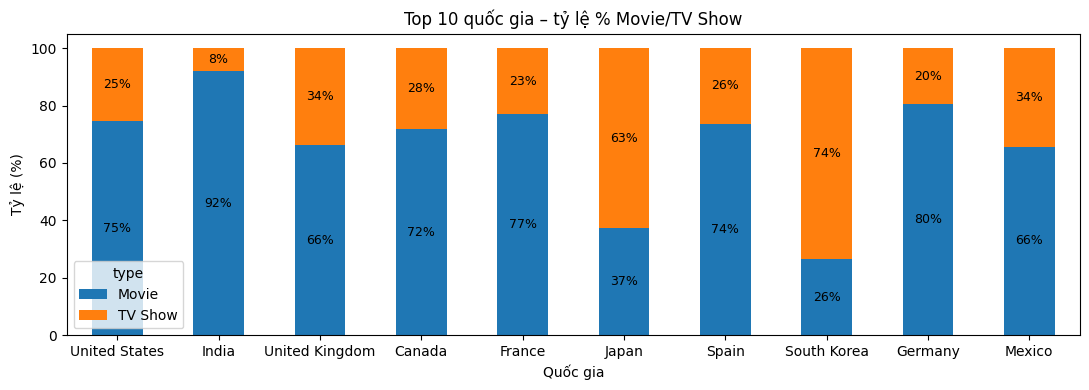

In [39]:
wide = (tmp[tmp["country"].isin(top10)]
        .pivot_table(index="country", columns="type", values="show_id",
                     aggfunc="count", fill_value=0))
order = wide.sum(axis=1).sort_values(ascending=False).index
wide = wide.loc[order]
share = (wide.div(wide.sum(axis=1), axis=0)*100).round(1)
ax = share.plot(kind="bar", stacked=True, figsize=(11,4))
ax.set_title("Top 10 quốc gia – tỷ lệ % Movie/TV Show")
ax.set_xlabel("Quốc gia"); ax.set_ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0, ha="center")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=9)
plt.tight_layout()
plt.show()


- Nhóm nghiêng mạnh về Movie
    + India ~92% Movie (TV Share rất nhỏ).
    + Germany ~80% Movie, France ~77%, Canada ~72%, Mexico ~66%, UK ~66%, US ~75% → các thị trường nói tiếng Anh (trừ US có TV cao hơn một chút) vẫn thiên Movie.
- Nhóm nghiêng mạnh về TV Show
    + South Korea ~74% TV, Spain ~74% TV, Japan ~63% TV → TV là định dạng chủ lực. Đây khớp bối cảnh: Hàn/Nhật có truyền thống series dài tập; Tây Ban Nha bùng nổ TV drama/thriller.
- So sánh nhanh:
    + US cân bằng hơn các nước khác (TV ~25%) nhưng vẫn thiên Movie.
    + Ấn Độ là ngoại lệ rõ nhất: “Movie” áp đảo.
    + Hàn-Nhật là các thị trường “TV Show”.
    + Các nước khác đều có Movie nhiều hơn hoặc gấp đôi TV Show

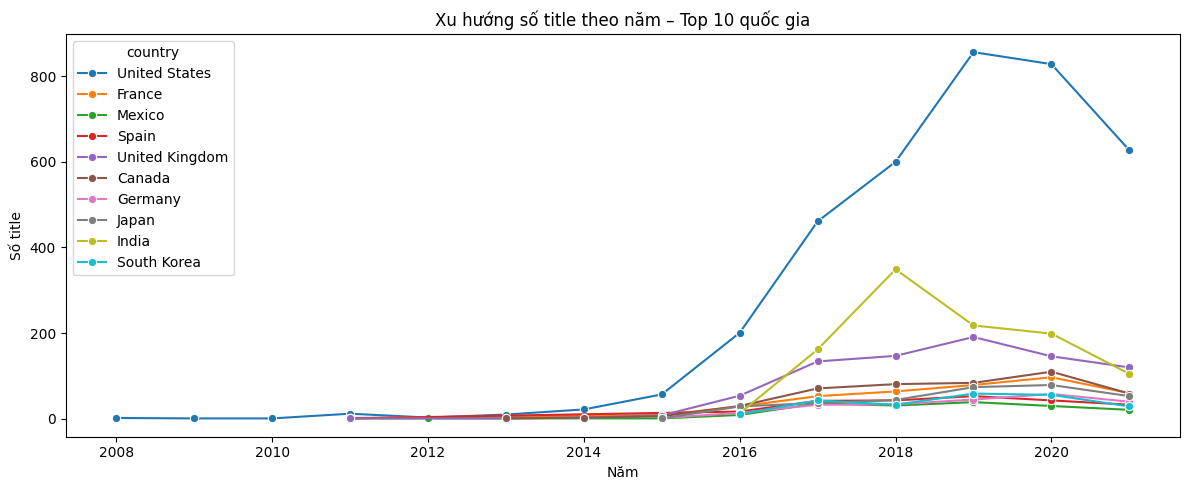

In [40]:
tmp = df.assign(country=df["country"].str.split(",")).explode("country")
tmp["country"] = tmp["country"].str.strip()
#đếm theo năm x quốc gia
trend = (tmp[tmp["country"].isin(top10)]
         .groupby(["added_year","country"], as_index=False)["show_id"].count()
         .rename(columns={"show_id":"count"}))
#line chart
plt.figure(figsize=(12,5))
ax = sns.lineplot(data=trend, x="added_year", y="count", hue="country", marker="o")
ax.set(title="Xu hướng số title theo năm – Top 10 quốc gia",
       xlabel="Năm", ylabel="Số title")
plt.xticks(rotation=0, ha="center")
plt.tight_layout(); plt.show()

- Nhận xét “Xu hướng số title theo năm – Top 10 quốc gia”:
    + Mỹ (United States) vượt trội rõ rệt và là động lực chính của toàn catalog: tăng mạnh từ 2016 → đỉnh 2019 (~850), sau đó giảm 2020–2021 (khả năng chịu tác động từ COVID & điều chỉnh nội dung/licensing).
    + Ấn Độ bứt phá nhanh nhất trong nhóm còn lại: nhảy vọt 2017–2018 (đỉnh ~330–350) rồi hạ nhiệt từ 2019, nhưng vẫn duy trì mức cao so với châu Âu.
    + Anh, Canada, Pháp, Tây Ban Nha cùng xu hướng: tăng đều 2016–2019, đỉnh vào 2019–2020, sau đó giảm nhẹ 2021.
    + Hàn Quốc & Nhật Bản tăng ổn định 2017–2020 (nhờ TV dramas/series), giảm 2021 nhưng vẫn cao hơn giai đoạn trước 2017.
- Điểm ngoặt toàn biểu đồ là từ 2016 (catalog mở rộng mạnh), và 2019 là năm đỉnh của hầu hết quốc gia; 2020–2021 ghi nhận suy giảm chung.

In [41]:
tmp = df.assign(country=df["country"].str.split(",")).explode("country")
tmp["country"] = tmp["country"].str.strip()

tmp["region"] = tmp["country"].eq("United States").map({True:"US", False:"International"})
share_total = (tmp.drop_duplicates(["show_id"])  # mỗi title chỉ tính 1 lần
                 ["region"].value_counts(normalize=True)*100).round(1)
print(share_total)  # -> % US vs International (tổng thể)

region
International    63.6
US               36.4
Name: proportion, dtype: float64


In [42]:
tmp["region"] = tmp["country"].eq("United States").map({True:"US", False:"International"})
by_type = (tmp.drop_duplicates(["show_id"])
             .groupby(["region","type"])["show_id"].count()
             .groupby(level=0).apply(lambda s: (s/s.sum()*100).round(1)))
print(by_type)  # % Movie/TV trong từng region

region         region         type   
International  International  Movie      67.3
                              TV Show    32.7
US             US             Movie      73.6
                              TV Show    26.4
Name: show_id, dtype: float64


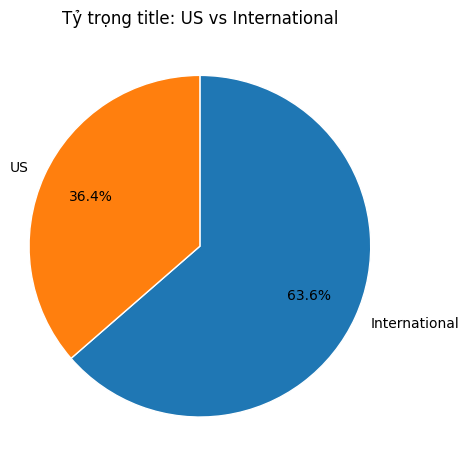

In [43]:
labels = share_total.index.tolist()      
sizes  = share_total.values              
plt.figure(figsize=(4.8,4.8))

centre = plt.pie(sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops=dict(linewidth=1, edgecolor='white'),  
    pctdistance=0.7 ); 
plt.title("Tỷ trọng title: US vs International")
plt.axis('equal')   #
plt.tight_layout()
plt.savefig(
    "../images/us_vs_international_share.png",
    bbox_inches='tight'
)
plt.show()

- Biểu đồ cho thấy International ~63.5% và US ~36.5% → thư viện Netflix  hiện nghiêng về nội dung quốc tế (không phải Mỹ).
- Điều này phù hợp với xu hướng  đã vẽ trước đó: từ ~2017–2019 số title quốc tế tăng mạnh, trong khi US vẫn lớn nhưng không chiếm đa số.

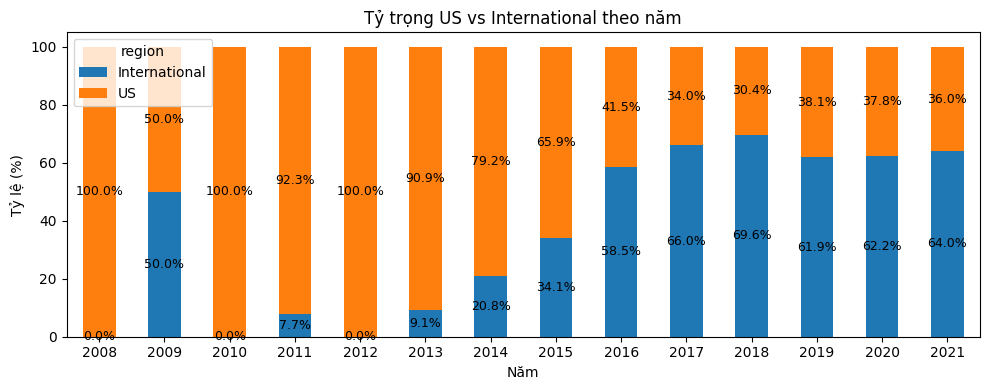

In [44]:
# Tạo cột region: US vs International (nếu chưa có)
tmp = (df.assign(country=df["country"].str.split(","))
         .explode("country"))
tmp["country"] = tmp["country"].str.strip()
tmp["region"]  = tmp["country"].eq("United States").map({True:"US", False:"International"})

# Đếm số title theo năm × region (mỗi title tính 1 lần)
by_year = (tmp.drop_duplicates("show_id")
             .groupby(["added_year","region"], as_index=False)
             .agg(count=("show_id","size")))

# Tính % trong từng năm
by_year["pct"] = (by_year.groupby("added_year")["count"]
                          .transform(lambda s: (s/s.sum()*100).round(1)))

# Vẽ stacked %
pvt = by_year.pivot(index="added_year", columns="region", values="pct").fillna(0)
ax = pvt.plot(kind="bar", stacked=True, figsize=(10,4))
ax.set_title("Tỷ trọng US vs International theo năm")
ax.set_xlabel("Năm"); ax.set_ylabel("Tỷ lệ (%)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", fontsize=9)
plt.xticks(rotation=0, ha="center")
plt.tight_layout(); plt.show()


- 2008–2012: International gần như 100% (US rất ít/không có). Giai đoạn này số lượng title còn thấp nên tỷ trọng dễ “nhảy”.
- 2013–2015: US bắt đầu tăng nhanh; đến 2015 ~34% US.
- 2016–2018: US bứt phá mạnh, đạt đỉnh khoảng 2018 ~70% US (International ~30%). Đây là thời kỳ mở rộng nội dung Mỹ rõ rệt.
- 2019–2021: Tỷ trọng US giảm nhẹ nhưng vẫn chiếm đa số (~62–64% US), International tăng lên 36–38% → dấu hiệu đa dạng hoá nguồn nội dung ngoài Mỹ.

In [45]:
# Chuẩn hoá nhẹ để so sánh
rat = df['rating'].astype(str).str.strip()
# Top giá trị xuất hiện nhiều
rat.value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [46]:
from scipy.stats import chi2_contingency

In [47]:
def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    phi2 = chi2/n
    # bias correction
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

# Ví dụ: type vs rating
ct = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, _ = chi2_contingency(ct)
print("Chi-square p-value:", p)
print("Cramér’s V:", cramers_v(ct))


Chi-square p-value: 1.9295838438999808e-215
Cramér’s V: 0.34261667368146376


In [48]:
# Bảng chéo & kỳ vọng
ct = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, expected = chi2_contingency(ct)

# Residual chuẩn hoá
std_resid = (ct - expected) / np.sqrt(expected)
print(std_resid.round(2))       # >0: quan sát > kỳ vọng; <0: quan sát < kỳ vọng

rating      G  NC-17    NR    PG  PG-13      R  TV-14  TV-G  TV-MA  TV-PG  \
type                                                                        
Movie    2.33   0.63  2.59  6.17   8.06  10.21  -1.97 -2.19  -3.62  -2.48   
TV Show -3.53  -0.95 -3.92 -9.34 -12.20 -15.46   2.98  3.32   5.47   3.75   

rating   TV-Y  TV-Y7  TV-Y7-FV    UR  
type                                  
Movie   -5.66  -6.13      0.40  0.63  
TV Show  8.56   9.28     -0.61 -0.95  


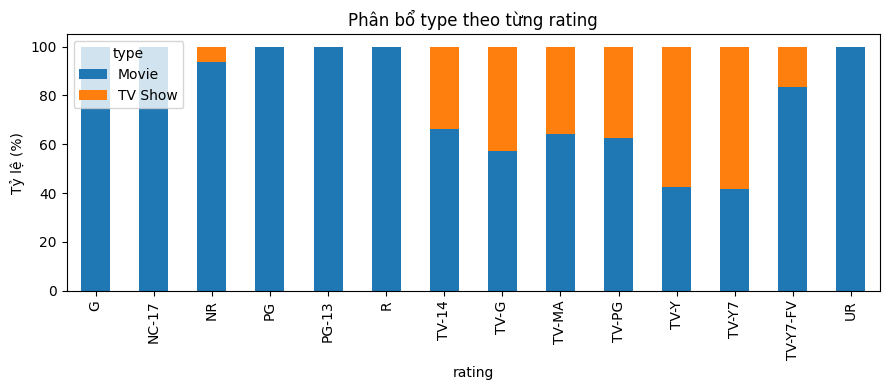

In [49]:
share = (ct.div(ct.sum(axis=0), axis=1)*100).T  # mỗi cột rating chuẩn hoá %
share.plot(kind="bar", stacked=True, figsize=(9,4))
plt.ylabel("Tỷ lệ (%)"); plt.title("Phân bổ type theo từng rating")
plt.tight_layout(); plt.show()

- Ranh giới rõ theo hệ chuẩn:
- Các nhãn MPAA (G, PG, PG-13, R, NC-17, NR/UR) gần như 100% là Movie.
- Nhãn TV chủ yếu là TV Show:
    + TV-MA, TV-14 chiếm tỷ lệ lớn của TV Show; TV-PG cũng nghiêng về TV Show.
    + Nhóm  TV-Y, TV-Y7 đa phần TV Show (vẫn còn một phần Movie do phim đặc biệt/ghi nhãn chéo).
- NR: Nghiêng về Movie.

In [50]:
# Lấy danh sách cột genre_*
genre_cols = [c for c in df.columns if c.startswith("genre_")]
# Argmax theo hàng: chọn cột 1 cao nhất làm main_genre
import numpy as np
vals = df[genre_cols].to_numpy()
imax = vals.argmax(axis=1)                    # vị trí cột có giá trị lớn nhất
has_any = vals.max(axis=1) > 0                # hàng không có thể loại nào
main = np.where(
    has_any,
    np.array(genre_cols)[imax],               # tên cột genre_*
    "genre_Unknown"
)
# Bỏ prefix 'genre_' để gọn
df["main_genre"] = pd.Series(main).astype(str).str.replace(r"^genre_", "", regex=True)

main_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                828
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              333
Horror Movies                275
British TV Shows             253
Docuseries                   221
Anime Series                 176
International Movies         128
TV Comedies                  120
Name: count, dtype: int64

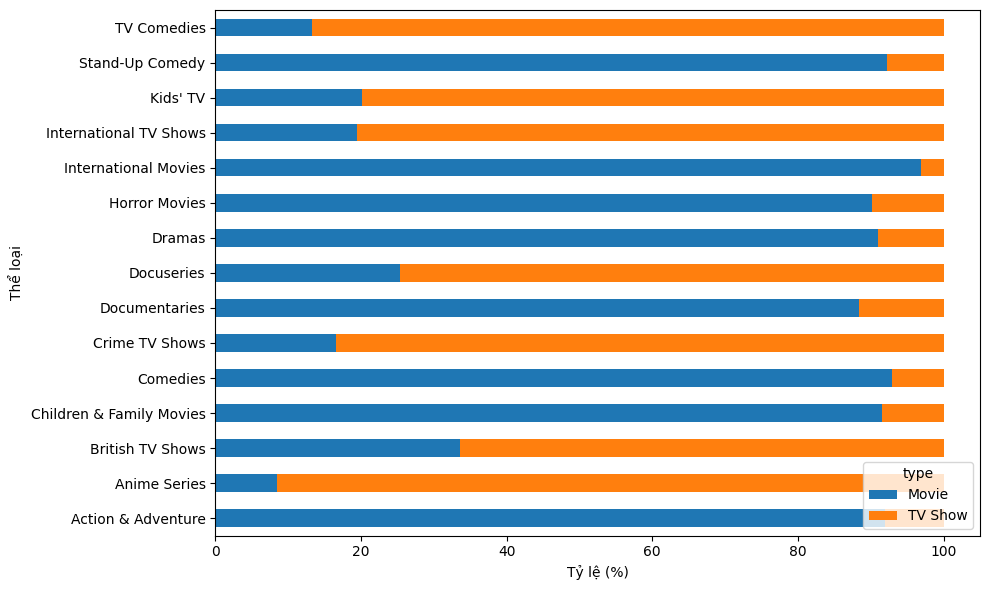

In [51]:
# Top 15 main_genre
topg = df["main_genre"].value_counts().head(15)
display(topg)
# Stacked %: type (Movie/TV Show) theo main_genre (top)
mask = df["main_genre"].isin(topg.index)
ct = pd.crosstab(df.loc[mask, "type"], df.loc[mask, "main_genre"])
share = (ct / ct.sum(axis=0) * 100).T
ax = share.plot(kind="barh", stacked=True, figsize=(10,6))
ax.set_xlabel("Tỷ lệ (%)")
ax.set_ylabel("Thể loại")
ax.legend(title="type", loc="lower right")
plt.tight_layout(); plt.show()

- Nhóm nghiêng mạnh về TV Show (≈≥80%):
    + TV Comedies, Kids’ TV, International TV Shows, Crime TV Shows, Anime Series, British TV Shows. → các thể loại có chữ “TV/Series” gần như thuần TV Show.
- Nhóm nghiêng mạnh về Movie (≈≥80%):
Action & Adventure, Horror Movies, Dramas, Children & Family Movies, International Movies. → các thể loại “Movies” gần như thuần phim lẻ.
- Nhóm “lai” đáng chú ý:
    + Documentaries thiên Movie nhưng vẫn có phần TV; Docuseries lại thiên TV Show → cùng là “tài liệu” nhưng khác định dạng (phim tài liệu vs series tài liệu).
    + Comedies có xu hướng Movie-heavy nhưng vẫn có tỷ lệ TV Show.
